# K-Nearest Neighbours with NumPy
Vectorised pairwise distance computation — no sklearn in the core logic.
Includes weighted KNN and cross-validation. Model saved to `../Models/knn_numpy.npz`.

## 1. Load & Split Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

iris        = load_iris()
features    = list(iris.feature_names)
class_names = list(iris.target_names)
X, y        = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 120  |  Test: 30


## 2. Feature Standardisation

In [2]:
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0, ddof=1)

X_train_sc = (X_train - X_mean) / X_std
X_test_sc  = (X_test  - X_mean) / X_std

## 3. Vectorised Pairwise Distance

The naive approach loops over every test point to compute distances — O(n_test × n_train × p).
NumPy broadcasting collapses this into a single tensor operation:

```
X_test  shape: (n_test, p)
X_train shape: (n_train, p)

diff    shape: (n_test, n_train, p)   ← broadcasting
dist    shape: (n_test, n_train)      ← sum over last axis + sqrt
```

In [3]:
def pairwise_euclidean(X_test: np.ndarray, X_train: np.ndarray) -> np.ndarray:
    """
    Returns distance matrix D of shape (n_test, n_train).
    D[i, j] = Euclidean distance from test point i to train point j.
    """
    diff = X_test[:, np.newaxis, :] - X_train[np.newaxis, :, :]  # (n_test, n_train, p)
    return np.sqrt((diff ** 2).sum(axis=2))                       # (n_test, n_train)


def pairwise_manhattan(X_test: np.ndarray, X_train: np.ndarray) -> np.ndarray:
    diff = X_test[:, np.newaxis, :] - X_train[np.newaxis, :, :]  # (n_test, n_train, p)
    return np.abs(diff).sum(axis=2)                               # (n_test, n_train)


# Quick sanity check
D = pairwise_euclidean(X_test_sc, X_train_sc)
print(f"Distance matrix shape: {D.shape}  (n_test × n_train)")
print(f"Min distance: {D.min():.4f}  |  Max: {D.max():.4f}")

Distance matrix shape: (30, 120)  (n_test × n_train)
Min distance: 0.1189  |  Max: 6.1051


## 4. KNN Predict & Predict Proba

In [4]:
def knn_predict(dist_matrix: np.ndarray, y_train: np.ndarray, k: int) -> np.ndarray:
    """
    Given precomputed distance matrix (n_test, n_train),
    return predicted class labels (n_test,).
    """
    # argsort each row → indices of train points sorted by distance
    nn_idx  = np.argsort(dist_matrix, axis=1)[:, :k]     # (n_test, k)
    nn_lbls = y_train[nn_idx]                              # (n_test, k)

    # Majority vote — fastest with np.apply_along_axis + bincount
    n_classes = len(np.unique(y_train))
    votes     = np.apply_along_axis(
        lambda row: np.bincount(row, minlength=n_classes), axis=1, arr=nn_lbls
    )                                                      # (n_test, n_classes)
    return np.argmax(votes, axis=1)                        # (n_test,)


def knn_predict_proba(dist_matrix: np.ndarray, y_train: np.ndarray,
                      k: int, n_classes: int) -> np.ndarray:
    """Return class probability matrix (n_test, n_classes)."""
    nn_idx  = np.argsort(dist_matrix, axis=1)[:, :k]
    nn_lbls = y_train[nn_idx]
    votes   = np.apply_along_axis(
        lambda row: np.bincount(row, minlength=n_classes), axis=1, arr=nn_lbls
    )
    return votes / k                                       # (n_test, n_classes)


def knn_predict_weighted(dist_matrix: np.ndarray, y_train: np.ndarray,
                         k: int, n_classes: int) -> np.ndarray:
    """
    Inverse-distance weighted KNN.
    Closer neighbours contribute more to the vote.
    w_i = 1 / (d_i + eps)
    """
    eps     = 1e-10
    idx     = np.argsort(dist_matrix, axis=1)[:, :k]      # (n_test, k)
    dists   = np.take_along_axis(dist_matrix, idx, axis=1) # (n_test, k)
    weights = 1.0 / (dists + eps)                          # (n_test, k)
    lbls    = y_train[idx]                                  # (n_test, k)

    votes   = np.zeros((len(dist_matrix), n_classes))
    for c in range(n_classes):
        votes[:, c] = (weights * (lbls == c)).sum(axis=1)
    return np.argmax(votes, axis=1)

## 5. Evaluate (k=5, Uniform + Weighted)

In [5]:
K        = 5
n_cls    = len(class_names)
D_train  = pairwise_euclidean(X_train_sc, X_train_sc)
D_test   = pairwise_euclidean(X_test_sc,  X_train_sc)

y_pred        = knn_predict(D_test, y_train, k=K)
y_proba       = knn_predict_proba(D_test, y_train, k=K, n_classes=n_cls)
y_pred_wtd    = knn_predict_weighted(D_test, y_train, k=K, n_classes=n_cls)

print(f"Uniform  KNN (k={K}): {accuracy_score(y_test, y_pred):.4f}")
print(f"Weighted KNN (k={K}): {accuracy_score(y_test, y_pred_wtd):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names))

Uniform  KNN (k=5): 0.9333
Weighted KNN (k=5): 0.9667

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## 6. Confusion Matrix

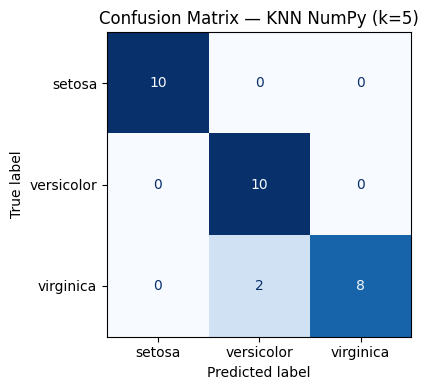

In [6]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — KNN NumPy (k={K})')
plt.tight_layout(); plt.show()

## 7. k Sweep — Uniform vs Weighted

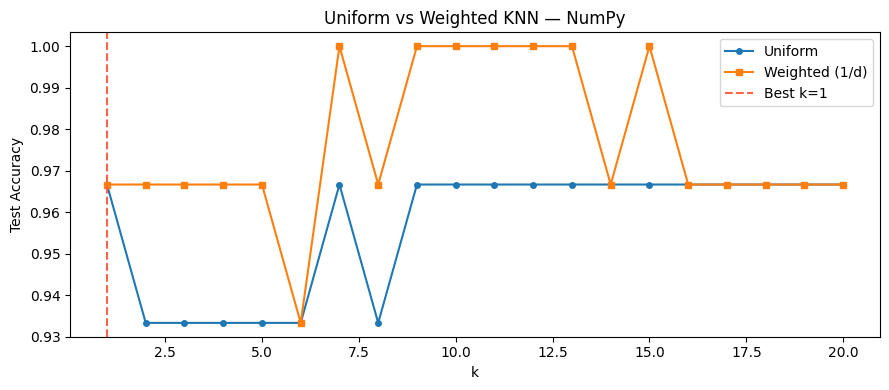

In [7]:
k_range  = range(1, 21)
acc_uni  = [accuracy_score(y_test, knn_predict(D_test, y_train, k)) for k in k_range]
acc_wtd  = [accuracy_score(y_test, knn_predict_weighted(D_test, y_train, k, n_cls)) for k in k_range]

best_k   = list(k_range)[np.argmax(acc_uni)]

plt.figure(figsize=(9, 4))
plt.plot(k_range, acc_uni, marker='o', markersize=4, label='Uniform')
plt.plot(k_range, acc_wtd, marker='s', markersize=4, label='Weighted (1/d)')
plt.axvline(best_k, linestyle='--', color='tomato', label=f'Best k={best_k}')
plt.xlabel('k'); plt.ylabel('Test Accuracy')
plt.title('Uniform vs Weighted KNN — NumPy')
plt.legend(); plt.tight_layout(); plt.show()

## 8. Distance Metric Comparison

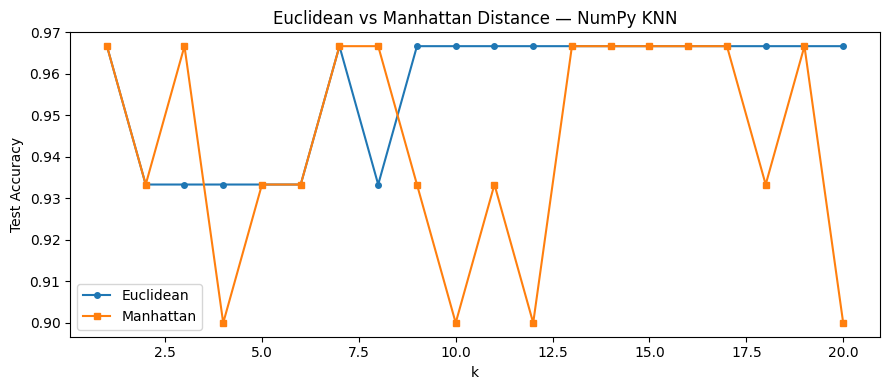

Euclidean best: k=1  acc=0.9667
Manhattan best: k=1  acc=0.9667


In [8]:
D_man = pairwise_manhattan(X_test_sc, X_train_sc)

acc_euc = [accuracy_score(y_test, knn_predict(D_test, y_train, k)) for k in k_range]
acc_man = [accuracy_score(y_test, knn_predict(D_man,  y_train, k)) for k in k_range]

plt.figure(figsize=(9, 4))
plt.plot(k_range, acc_euc, marker='o', markersize=4, label='Euclidean')
plt.plot(k_range, acc_man, marker='s', markersize=4, label='Manhattan')
plt.xlabel('k'); plt.ylabel('Test Accuracy')
plt.title('Euclidean vs Manhattan Distance — NumPy KNN')
plt.legend(); plt.tight_layout(); plt.show()

print(f"Euclidean best: k={list(k_range)[np.argmax(acc_euc)]}  acc={max(acc_euc):.4f}")
print(f"Manhattan best: k={list(k_range)[np.argmax(acc_man)]}  acc={max(acc_man):.4f}")

## 9. Manual Cross-Validation (5-fold)

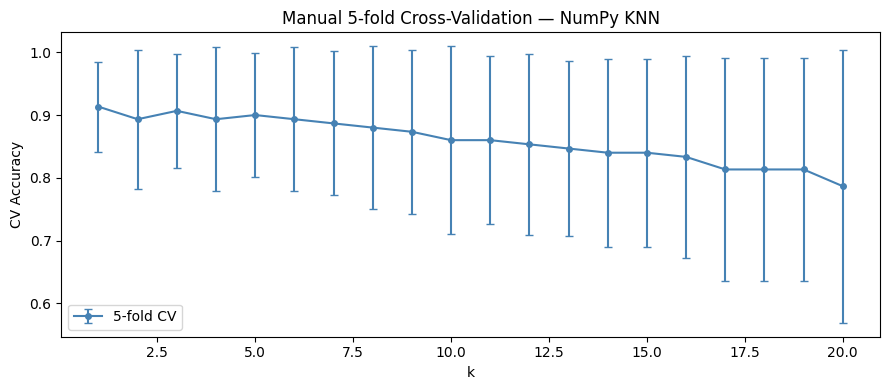

Best CV k=1  acc=0.9133


In [9]:
def manual_kfold_cv(X, y, k_neighbours, n_folds=5):
    """Pure numpy k-fold cross-validation for KNN."""
    n       = len(X)
    idx     = np.arange(n)
    folds   = np.array_split(idx, n_folds)
    scores  = []

    X_mean_ = X.mean(axis=0);  X_std_ = X.std(axis=0, ddof=1)

    for fold_idx in range(n_folds):
        val_idx   = folds[fold_idx]
        train_idx = np.concatenate([folds[i] for i in range(n_folds) if i != fold_idx])

        X_tr = (X[train_idx] - X_mean_) / X_std_
        X_va = (X[val_idx]   - X_mean_) / X_std_
        y_tr = y[train_idx];  y_va = y[val_idx]

        D_va    = pairwise_euclidean(X_va, X_tr)
        y_pred_ = knn_predict(D_va, y_tr, k=k_neighbours)
        scores.append(accuracy_score(y_va, y_pred_))

    return np.array(scores)


cv_means, cv_stds = [], []
for k in k_range:
    s = manual_kfold_cv(X, y, k_neighbours=k)
    cv_means.append(s.mean()); cv_stds.append(s.std())

plt.figure(figsize=(9, 4))
plt.errorbar(k_range, cv_means, yerr=cv_stds, marker='o', markersize=4,
             capsize=3, color='steelblue', label='5-fold CV')
plt.xlabel('k'); plt.ylabel('CV Accuracy')
plt.title('Manual 5-fold Cross-Validation — NumPy KNN')
plt.legend(); plt.tight_layout(); plt.show()
print(f"Best CV k={list(k_range)[np.argmax(cv_means)]}  acc={max(cv_means):.4f}")

## 10. Save Model to `../Models/`

In [10]:
save_path = '../Models/knn_numpy.npz'
np.savez_compressed(
    save_path,
    X_train  = X_train_sc,   # (n_train, p) — scaled training data
    y_train  = y_train,      # (n_train,)
    x_mean   = X_mean,       # (p,)
    x_std    = X_std,        # (p,)
    k        = np.array(K)
)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/knn_numpy.npz  (2.6 KB)
